# Plotting OLS vs Cor results of SEACElls

In [2]:
#read in the results from correlation analysis, then aggregate
import pandas as pd

cor_res_100kb = pd.read_csv("/home/fgsasse_lrs_1/Downloads/BA/BA_data/Correlations/Results/gene_peak_correlation_sc_100kb_results.csv")
cor_res_100kb.head()

# classify every peak–gene pair into one of three categories
def classify_pair(row):
    if row["padj"] <= 0.05 and row["correlation"] < 0:
        return "sig. negative"
    elif row["padj"] <= 0.05 and row["correlation"] > 0:
        return "sig. positive"
    else:
        return "non-significant"

cor_res_100kb["category"] = cor_res_100kb.apply(classify_pair, axis=1)

#aggregate the number of significant peaks per gene and category  
agg_cor_100kb_df = (
    cor_res_100kb
    .dropna(subset=["correlation", "padj", "category"])
    .groupby(["window", "gene", "category"])
    .size()
    .reset_index(name="count")
)
agg_cor_100kb_df.head()

,window,gene,category,count
0,100kb,a1cf,non-significant,38
1,100kb,a1cf,sig. positive,57
2,100kb,a2ml,non-significant,35
3,100kb,a2ml,sig. positive,42
4,100kb,aaas,non-significant,19


In [3]:
#read in the saved all_ols_dfs dataframe to confirm it was saved correctly
ols_res_df = pd.read_csv("/home/fgsasse_lrs_1/Downloads/BA/BA_data/OLS/Results/ols_results_100kb_df_sc.csv")
ols_res_100kb = ols_res_df[ols_res_df["window"] == "100kb"].copy()
ols_res_100kb.head()

#aggregate the number of significant peaks per gene and category for OLS results
agg_ols_100kb_df = (
    ols_res_100kb
    .dropna(subset=["pval", "coef", "category"])
    .groupby(["window", "gene", "category"]) 
    .size()
    .reset_index(name="count")
)
agg_ols_100kb_df.head()

,window,gene,category,count
0,100kb,a1cf,non-significant,90
1,100kb,a1cf,sig. negative,3
2,100kb,a1cf,sig. positive,2
3,100kb,a2ml,non-significant,74
4,100kb,a2ml,sig. negative,1


In [4]:
#merge the two aggregated dataframes on window, gene to compare the number of significant peaks per gene and category between correlation and OLS results

#rename the count column in agg_cor_100kb_df to count_cor to avoid confusion with the count column in agg_ols_100kb_df
agg_cor_100kb_df["count_cor"] = agg_cor_100kb_df['count']
agg_ols_100kb_df["count_ols"] = agg_ols_100kb_df['count']

agg_merged_df = pd.merge(
    agg_cor_100kb_df,
    agg_ols_100kb_df,
    on=["window", "gene", "category"],
    how="outer",
)
agg_merged_df.head() 

,window,gene,category,count_x,count_cor,count_y,count_ols
0,100kb,a1cf,non-significant,38.0,38.0,90.0,90.0
1,100kb,a1cf,sig. negative,NaN,NaN,3.0,3.0
2,100kb,a1cf,sig. positive,57.0,57.0,2.0,2.0
3,100kb,a2ml,non-significant,35.0,35.0,74.0,74.0
4,100kb,a2ml,sig. negative,NaN,NaN,1.0,1.0


/tmp/ipykernel_3448144/740243026.py:25: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  plot_sig_df["n_genes"] = plot_sig_df.groupby(


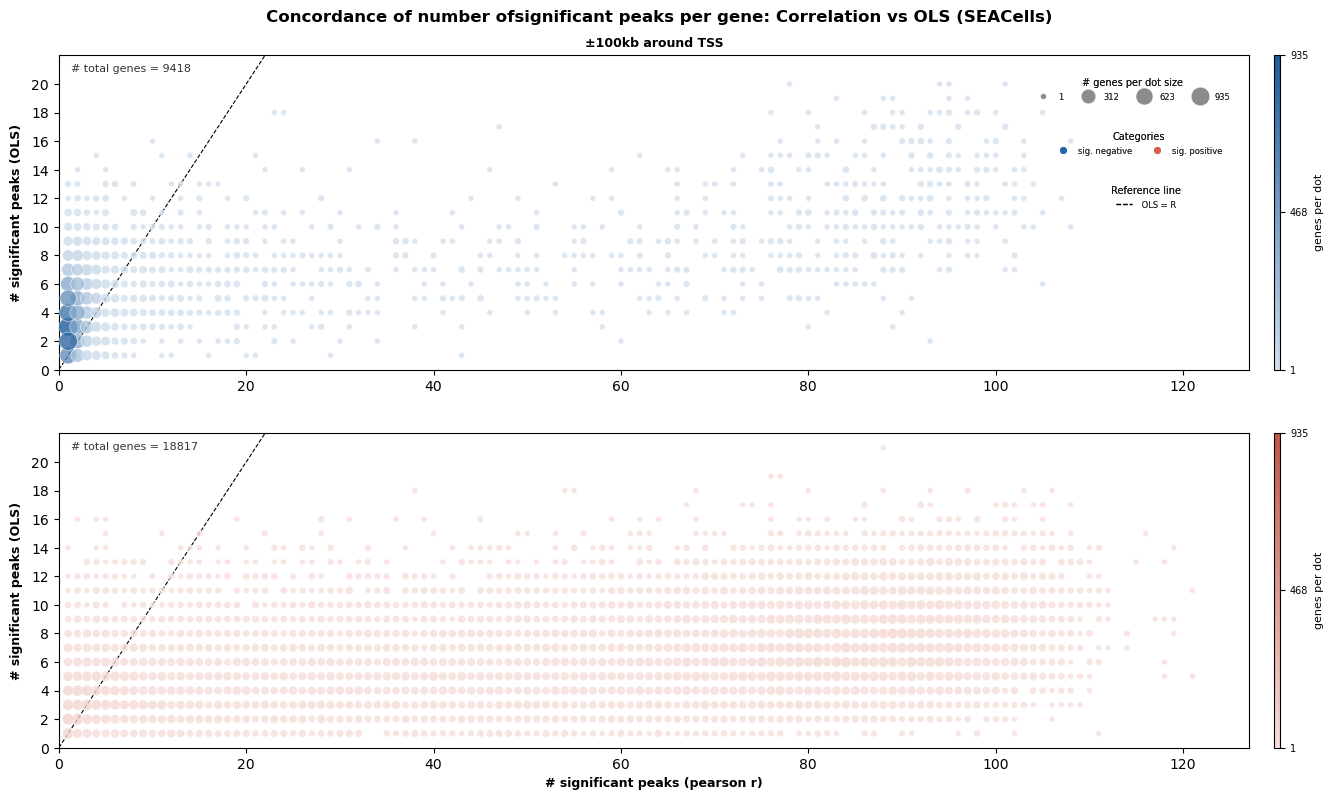

In [15]:
#plot the number of significant peaks per gene in correlation vs OLS results, colored by category and faceted by window & category
from tkinter import font

from matplotlib.lines import Line2D
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np
import pandas as pd

plot_df = agg_merged_df.dropna(subset=["count_cor", "count_ols", "window", "category", "gene"]).copy()
plot_df["window"] = pd.Categorical(
    plot_df["window"], categories=["100kb"], ordered=True,
)
plot_df["category"] = pd.Categorical(
    plot_df["category"],
    categories=["sig. negative", "non-significant", "sig. positive"], ordered=True,
)

plot_sig_df = plot_df[plot_df["category"] != "non-significant"].copy()

# Count genes per (count_cor, count_ols, window, category) position
plot_sig_df["n_genes"] = plot_sig_df.groupby(
    ["window", "category", "count_cor", "count_ols"] 
)["gene"].transform("count")

category_base_colors = {
    "sig. negative": "#2166ac",
    "sig. positive": "#d6604d",
}
category_order = ["sig. negative", "sig. positive"]
windows = ["100kb"]

# Deduplicate to one row per unique (x, y, window, category) position
plot_dedup = plot_sig_df.drop_duplicates(
    subset=["count_cor", "count_ols", "window", "category"]
).copy()

# Global n_genes range for consistent size/color scaling
n_min = plot_dedup["n_genes"].min()
n_max = plot_dedup["n_genes"].max()

def make_alpha_cmap(hex_color):
    r, g, b = mcolors.to_rgb(hex_color)
    light = (1 - (1 - r) * 0.20, 1 - (1 - g) * 0.20, 1 - (1 - b) * 0.20)
    dark  = (r * 0.9, g * 0.9, b * 0.9)
    return mcolors.LinearSegmentedColormap.from_list("cat_cmap", [light, dark])
# ↑ removed hex_color midpoint — now light=n_min, dark=n_max, linear between them
def size_scale(n, n_min, n_max, s_min=18, s_max=180):
    """Map gene count to marker area (sqrt scaling feels more linear visually)."""
    if n_max == n_min:
        return (s_min + s_max) / 2
    return s_min + (s_max - s_min) * ((n - n_min) / (n_max - n_min)) ** 0.5
# plot: rows = categories, cols = windows, points colored by category 
fig, axes = plt.subplots(
    len(category_order), len(windows),
    figsize=(16, 9),
    sharex=False, sharey=True,
)

axis_max = plot_sig_df[["count_cor", "count_ols"]].max().max() 

for row_i, category in enumerate(category_order):
    cmap = make_alpha_cmap(category_base_colors[category])
    norm = Normalize(vmin=n_min, vmax=n_max) 
     # ✓ one colorbar per row, attached to the rightmost axis
    sm = ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])
    cbar = fig.colorbar(
        sm,
        ax=axes[row_i],   # spans all axes in this row
        orientation="vertical",
        fraction=0.02,        # thin bar
        pad=0.02,
        aspect=50,
    )
    cbar.set_label("genes per dot", fontsize=8)
    cbar.ax.tick_params(labelsize=7)
    # tick at n_min, midpoint, n_max
    cbar.set_ticks([n_min, (n_min + n_max) // 2, n_max])

    for col_i, window in enumerate(windows):
        ax = axes[row_i]
        data = plot_dedup[
            (plot_dedup["window"] == window) &
            (plot_dedup["category"] == category)
        ]

        if not data.empty:
            sizes  = data["n_genes"].apply(lambda n: size_scale(n, n_min, n_max))
            colors = cmap(norm(data["n_genes"]))

            ax.scatter(
                data["count_cor"], data["count_ols"],
                c=colors, s = sizes,
                edgecolors="w", linewidths=0.4, zorder=3, alpha =0.8, 
            )

        ax.plot([0, axis_max], [0, axis_max],
                color="k", linestyle="--", linewidth=0.8, zorder=0)
        ax.set_xlim(0, axis_max*1.05)
        ax.set_ylim(0, plot_sig_df[ "count_ols"].max()*1.05)

        if row_i == 0:
            ax.set_title("±100kb around TSS", fontsize=9, fontweight="bold")
        if col_i == 0:
            ax.set_ylabel("# significant peaks (OLS)", fontsize=9, labelpad=6,fontweight="bold")
        else:
            ax.set_ylabel("")
        if row_i == len(category_order) - 1:
            ax.set_xlabel("# significant peaks (pearson r)", fontsize=9,fontweight="bold")
        else:
            ax.set_xlabel("")

        n_total = data["n_genes"].sum()
        ax.text(0.01,0.97, f"# total genes = {n_total}", transform=ax.transAxes,
                ha="left", va="top", fontsize=8, color="0.2") #on the right side to avoid overlap with y-axis
        
# ── Legend: size scale (two columns) ────────────────────────────────────────────
legend_counts = np.linspace(n_min, n_max, 4).astype(int)

size_handles = [
    Line2D([0], [0], marker="o", linestyle="",
           markersize=np.sqrt(size_scale(n, n_min, n_max)),
           markerfacecolor="0.55", markeredgecolor="w", markeredgewidth=0.4,
           label=str(n))
    for n in legend_counts
]

size_legend = fig.legend(
    handles=size_handles,
    title="# genes per dot size",
    loc="lower right",
    bbox_to_anchor=(0.862, 0.82),
    ncol= 4,
    frameon=False,
    fontsize=6,
    title_fontsize=7,
)

# bold + center the size legend's title (it's a separate Text object, easier to control)
size_legend.get_title().set_fontweight("roman")
size_legend.get_title().set_color("0.1")
size_legend.get_title().set_ha("center")
for text in size_legend.get_texts():
    text.set_color("0.2")
# ── Legend: categories ─────────────────────────────────────────────────────────
category_handles = [
    Line2D([0], [0], marker="o", linestyle="",
           markerfacecolor=category_base_colors[c],
           markeredgecolor=category_base_colors[c],
           markersize=4, label=c)
    for c in category_order
]

cat_legend = fig.legend(
    handles=category_handles,
    title="Categories",
    loc="lower right",
    bbox_to_anchor=(0.857, 0.76),
    ncol=2,
    frameon=False,
    fontsize=6,
    title_fontsize=7,
)
# bold + center the cat legend's title (it's a separate Text object, easier to control)
cat_legend.get_title().set_fontweight("roman")
cat_legend.get_title().set_ha("center")
cat_legend.get_title().set_color("0.1")
for text in cat_legend.get_texts():
    text.set_color("0.2")


# ── Legend: diagonal line ─────────────────────────────────────────────────────
line_handle = [
    Line2D([0], [0], color="k", linestyle="--", linewidth=0.9, label=" OLS = R")
]

line_legend = fig.legend(
    handles=line_handle,
    title="Reference line",
    loc="lower right",
    bbox_to_anchor=(0.831, 0.7),
    frameon=False,
    fontsize=6,
    title_fontsize=7,
)
# bold + center the size legend's title (it's a separate Text object, easier to control)
line_legend.get_title().set_fontweight("roman")
line_legend.get_title().set_color("0.1")
line_legend.get_title().set_ha("center")
for text in line_legend.get_texts():
    text.set_color("0.2")

fig.add_artist(cat_legend)  # ensure both persist (fig.legend can overwrite the previous one's reference internally in some mpl versions)
fig.add_artist(size_legend)  # ensure both persist (fig.legend can overwrite the previous one's reference internally in some mpl versions)
fig.add_artist(line_legend)  # ensure both persist (fig.legend can overwrite the previous one's reference internally in some mpl versions)

plt.yticks(np.arange(0, plot_sig_df[ "count_ols"].max()+ 1, 2))
plt.suptitle(
    "Concordance of number ofsignificant peaks per gene: Correlation vs OLS (SEACells)",
    fontsize=12, y= 0.93, fontweight="bold",
)

plt.show()



/tmp/ipykernel_3448144/2068906201.py:25: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  plot_non_sig_df["n_genes"] = plot_non_sig_df.groupby(


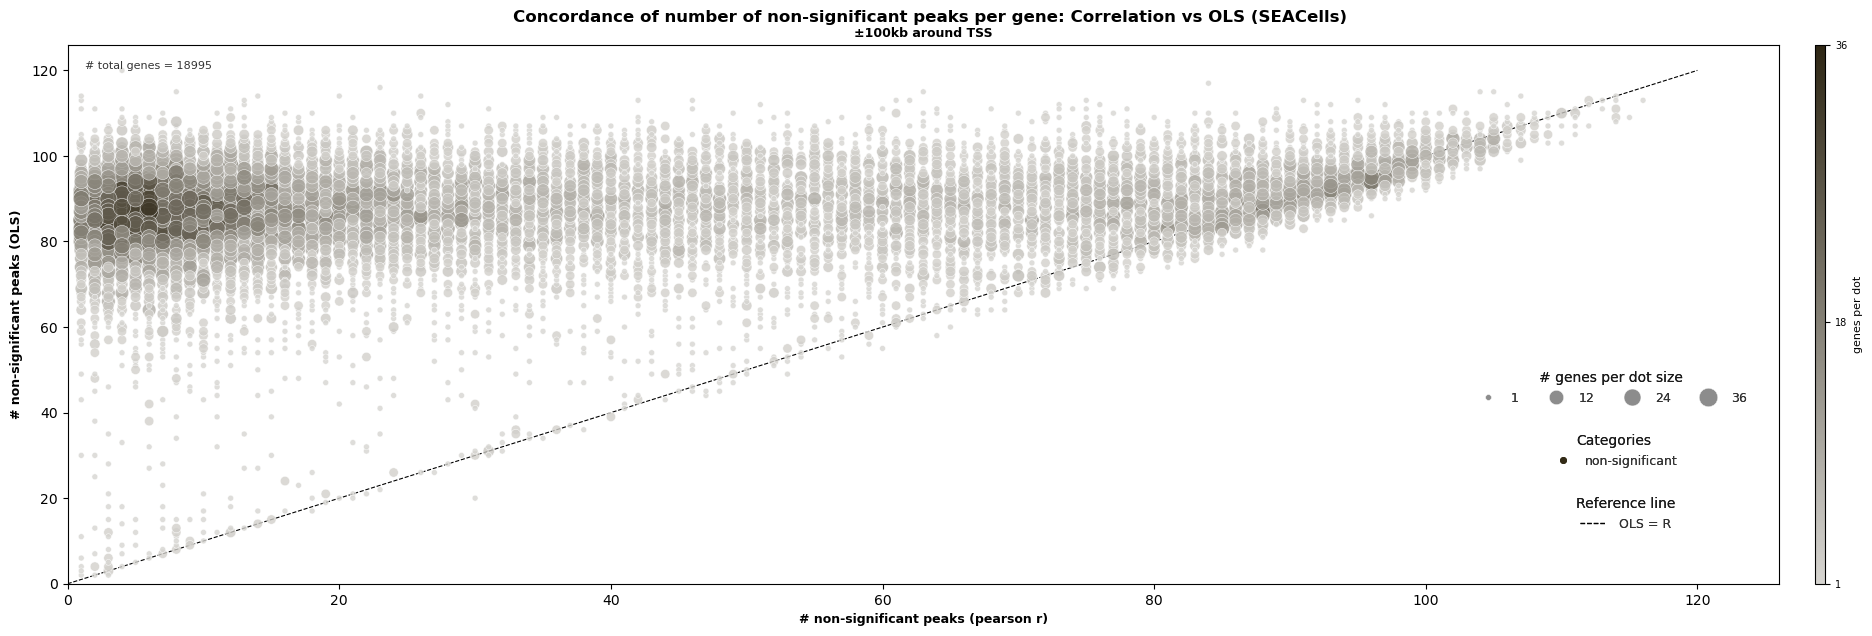

In [16]:
#plot the number of significant peaks per gene in correlation vs OLS results, colored by category and faceted by window & category
from tkinter import font

from matplotlib.lines import Line2D
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np
import pandas as pd

plot_df = agg_merged_df.dropna(subset=["count_cor", "count_ols", "window", "category", "gene"]).copy()
plot_df["window"] = pd.Categorical(
    plot_df["window"], categories=["100kb"], ordered=True,
)
plot_df["category"] = pd.Categorical(
    plot_df["category"],
    categories=["sig. negative", "non-significant", "sig. positive"], ordered=True,
)

plot_non_sig_df = plot_df[plot_df["category"] == "non-significant"].copy()

# Count genes per (count_cor, count_ols, window, category) position
plot_non_sig_df["n_genes"] = plot_non_sig_df.groupby(
    ["window", "category", "count_cor", "count_ols"] 
)["gene"].transform("count")

category_base_colors = {
    "non-significant": "#332b17",
}
category_order = ["non-significant"]
windows = ["100kb"]

# Deduplicate to one row per unique (x, y, window, category) position
plot_dedup = plot_non_sig_df.drop_duplicates(
    subset=["count_cor", "count_ols", "window", "category"]
).copy()

# Global n_genes range for consistent size/color scaling
n_min = plot_dedup["n_genes"].min()
n_max = plot_dedup["n_genes"].max()

def make_alpha_cmap(hex_color):
    r, g, b = mcolors.to_rgb(hex_color)
    light = (1 - (1 - r) * 0.20, 1 - (1 - g) * 0.20, 1 - (1 - b) * 0.20)
    dark  = (r * 0.9, g * 0.9, b * 0.9)
    return mcolors.LinearSegmentedColormap.from_list("cat_cmap", [light, dark])
# ↑ removed hex_color midpoint — now light=n_min, dark=n_max, linear between them
def size_scale(n, n_min, n_max, s_min=18, s_max=180):
    """Map gene count to marker area (sqrt scaling feels more linear visually)."""
    if n_max == n_min:
        return (s_min + s_max) / 2
    return s_min + (s_max - s_min) * ((n - n_min) / (n_max - n_min)) ** 0.5
# plot: rows = categories, cols = windows, points colored by category 
fig, axes = plt.subplots(
    len(category_order), len(windows),
    figsize=(23, 7),
    sharex=False, sharey=True,
)

axis_max = plot_non_sig_df[["count_cor", "count_ols"]].max().max() 

for row_i, category in enumerate(category_order):
    cmap = make_alpha_cmap(category_base_colors[category])
    norm = Normalize(vmin=n_min, vmax=n_max) 
     # ✓ one colorbar per row, attached to the rightmost axis
    sm = ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])
    cbar = fig.colorbar(
        sm,
        ax= axes,  # spans all axes in this row
        orientation="vertical",
        fraction=0.02,        # thin bar
        pad=0.02,
        aspect=50,
    )
    cbar.set_label("genes per dot", fontsize=8)
    cbar.ax.tick_params(labelsize=7)
    # tick at n_min, midpoint, n_max
    cbar.set_ticks([n_min, (n_min + n_max) // 2, n_max])

    for col_i, window in enumerate(windows):
        ax = axes
        data = plot_dedup[
            (plot_dedup["window"] == window) &
            (plot_dedup["category"] == category)
        ]

        if not data.empty:
            sizes  = data["n_genes"].apply(lambda n: size_scale(n, n_min, n_max))
            colors = cmap(norm(data["n_genes"]))

            ax.scatter(
                data["count_cor"], data["count_ols"],
                c=colors, s = sizes,
                edgecolors="w", linewidths=0.4, zorder=3, alpha =0.8, 
            )

        ax.plot([0, axis_max], [0, axis_max],
                color="k", linestyle="--", linewidth=0.8, zorder=0)
        ax.set_xlim(0, axis_max*1.05)
        ax.set_ylim(0, plot_non_sig_df[ "count_ols"].max()*1.05)

        if row_i == 0:
            ax.set_title("±100kb around TSS", fontsize=9, fontweight="bold")
        if col_i == 0:
            ax.set_ylabel("# non-significant peaks (OLS)", fontsize=9, labelpad=6,fontweight="bold")
        else:
            ax.set_ylabel("")
        if row_i == len(category_order) - 1:
            ax.set_xlabel("# non-significant peaks (pearson r)", fontsize=9,fontweight="bold")
        else:
            ax.set_xlabel("")

        n_total = data["n_genes"].sum()
        ax.text(0.01,0.97, f"# total genes = {n_total}", transform=ax.transAxes,
                ha="left", va="top", fontsize=8, color="0.2") #on the right side to avoid overlap with y-axis
        
# ── Legend: size scale (two columns) ────────────────────────────────────────────
legend_counts = np.linspace(n_min, n_max, 4).astype(int)

size_handles = [
    Line2D([0], [0], marker="o", linestyle="",
           markersize=np.sqrt(size_scale(n, n_min, n_max)),
           markerfacecolor="0.55", markeredgecolor="w", markeredgewidth=0.4,
           label=str(n))
    for n in legend_counts
]

size_legend = fig.legend(
    handles=size_handles,
    title="# genes per dot size",
    loc="lower right",
    bbox_to_anchor=(0.86, 0.35),
    ncol= 4,
    frameon=False,
    fontsize=9,
    title_fontsize=10,
)

# bold + center the size legend's title (it's a separate Text object, easier to control)
size_legend.get_title().set_fontweight("roman")
size_legend.get_title().set_color("0.1")
size_legend.get_title().set_ha("center")
for text in size_legend.get_texts():
    text.set_color("0.2")
# ── Legend: categories ─────────────────────────────────────────────────────────
category_handles = [
    Line2D([0], [0], marker="o", linestyle="",
           markerfacecolor=category_base_colors[c],
           markeredgecolor=category_base_colors[c],
           markersize=4, label=c)
    for c in category_order
]

cat_legend = fig.legend(
    handles=category_handles,
    title="Categories",
    loc="lower right",
    bbox_to_anchor=(0.83, 0.26),
    ncol=2,
    frameon=False,
    fontsize=9,
    title_fontsize=10,
)
# bold + center the cat legend's title (it's a separate Text object, easier to control)
cat_legend.get_title().set_fontweight("roman")
cat_legend.get_title().set_ha("center")
cat_legend.get_title().set_color("0.1")
for text in cat_legend.get_texts():
    text.set_color("0.2")


# ── Legend: diagonal line ─────────────────────────────────────────────────────
line_handle = [
    Line2D([0], [0], color="k", linestyle="--", linewidth=0.9, label=" OLS = R")
]

line_legend = fig.legend(
    handles=line_handle,
    title="Reference line",
    loc="lower right",
    bbox_to_anchor=(0.829, 0.17),
    frameon=False,
    fontsize=9,
    title_fontsize=10,
)
# bold + center the size legend's title (it's a separate Text object, easier to control)
line_legend.get_title().set_fontweight("roman")
line_legend.get_title().set_color("0.1")
line_legend.get_title().set_ha("center")
for text in line_legend.get_texts():
    text.set_color("0.2")

fig.add_artist(cat_legend)  # ensure both persist (fig.legend can overwrite the previous one's reference internally in some mpl versions)
fig.add_artist(size_legend)  # ensure both persist (fig.legend can overwrite the previous one's reference internally in some mpl versions)
fig.add_artist(line_legend)  # ensure both persist (fig.legend can overwrite the previous one's reference internally in some mpl versions)

plt.suptitle(
    "Concordance of number of non-significant peaks per gene: Correlation vs OLS (SEACells)",
    fontsize=12, y= 0.93, fontweight="bold",
)

plt.show()

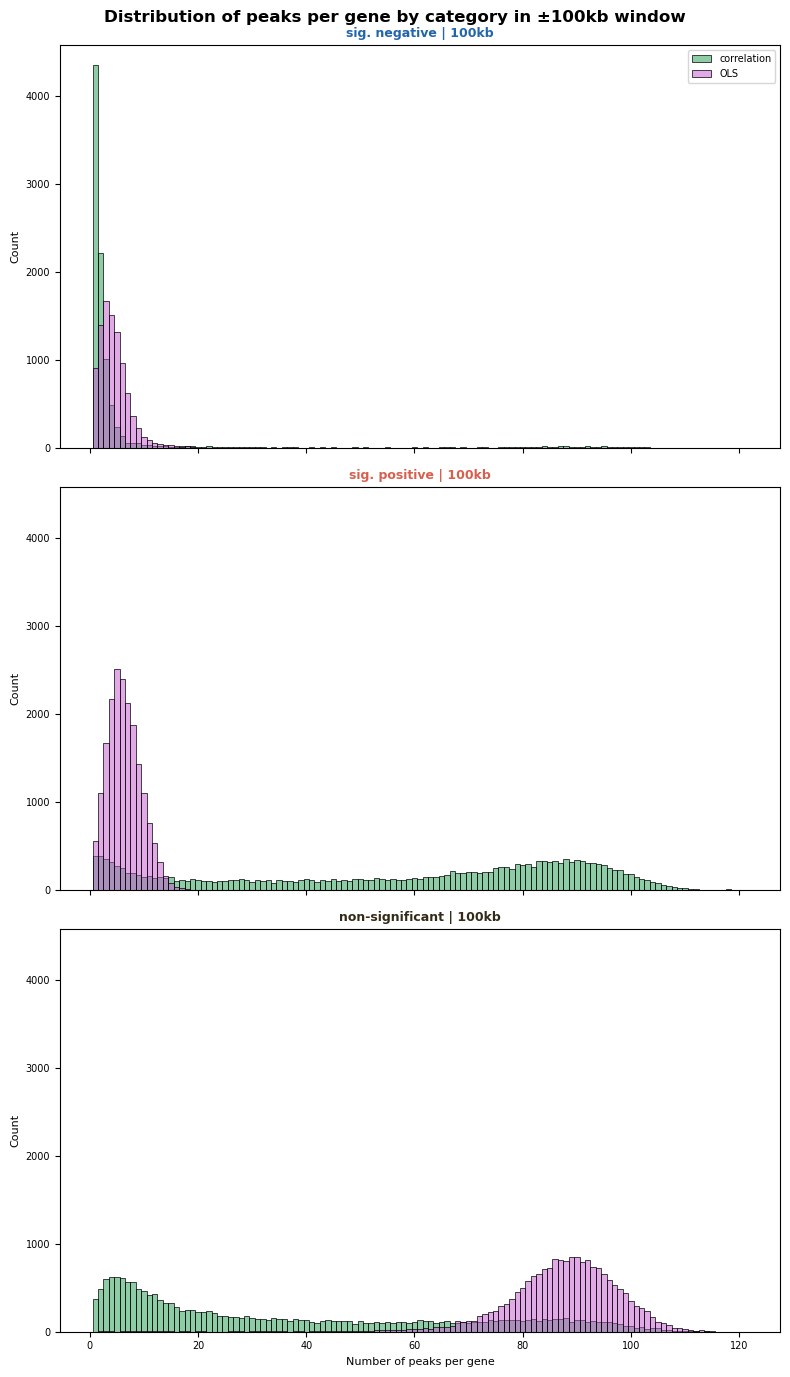

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

plot_df = agg_merged_df.dropna(subset=["count_cor", "count_ols", "window", "category", "gene"]).copy()
plot_df["window"] = pd.Categorical(
    plot_df["window"], categories=["100kb"], ordered=True,
)
plot_df["category"] = pd.Categorical(
    plot_df["category"],
    categories=["sig. negative", "non-significant", "sig. positive"], ordered=True,
)

plot_sig_df = plot_df.copy()
plot_sig_df["category"] = pd.Categorical(
    plot_sig_df["category"],
    categories=["sig. negative", "sig. positive", "non-significant"],
    ordered=True,
)

# Deduplicate to one row per unique (x, y, window, category) position
plot_dedup = plot_sig_df.drop_duplicates(
    subset=["count_cor", "count_ols", "window", "category"]
).copy()
category_order = ["sig. negative", "sig. positive", "non-significant"]
category_base_colors = {
    "sig. negative": "#2166ac",
    "sig. positive": "#d6604d",
    "non-significant": "#332b17",
}
window_labels = ["100kb"]
method_colors = {"correlation": "#1e9b4e", "OLS": "#c755d1"}

fig, axes = plt.subplots(len(category_order),1, figsize=(8, 14), sharex=True, sharey=True)

for row_idx, win in enumerate(window_labels):
    win_data = plot_sig_df[plot_sig_df["window"] == win]

    for col_idx, cat in enumerate(category_order):
        ax = axes[col_idx]
        cat_data = win_data[win_data["category"] == cat]

        combined_counts = pd.concat([win_data["count_cor"], win_data["count_ols"]]).dropna()
        if combined_counts.empty:
            ax.set_axis_off()
            continue

        bin_edges = np.linspace(combined_counts.min(), combined_counts.max(), 16)
        if np.unique(bin_edges).size < 2:
            bin_edges = np.array([combined_counts.min() - 0.5, combined_counts.max() + 0.5])

        # Plot correlation histogram
        sns.histplot(
            cat_data["count_cor"],
            #bins=bin_edges,
            alpha=0.5,
            label="correlation",
            color=method_colors["correlation"],
            edgecolor="black",
            linewidth=0.5,
            discrete=True,
            ax = ax

        )
        # Plot OLS histogram
        sns.histplot(
            cat_data["count_ols"],
            #bins=bin_edges,
            alpha=0.5,
            label="OLS",
            color=method_colors["OLS"],
            edgecolor="black",
            linewidth=0.5,
            discrete=True,
            ax = ax
        )

        ax.set_xlabel("Number of peaks per gene", fontsize=8)
        ax.set_ylabel("Count", fontsize=8)
        ax.set_title(f"{cat} | {win}", fontsize=9, fontweight="bold", color=category_base_colors.get(cat, "k"))
        ax.tick_params(labelsize=7)

        if row_idx == 0 and col_idx == 0:
            ax.legend(loc="upper right", fontsize=7)

fig.suptitle("Distribution of peaks per gene by category in ±100kb window", fontsize=12, fontweight="bold", y=0.98)
plt.tight_layout()
plt.show()

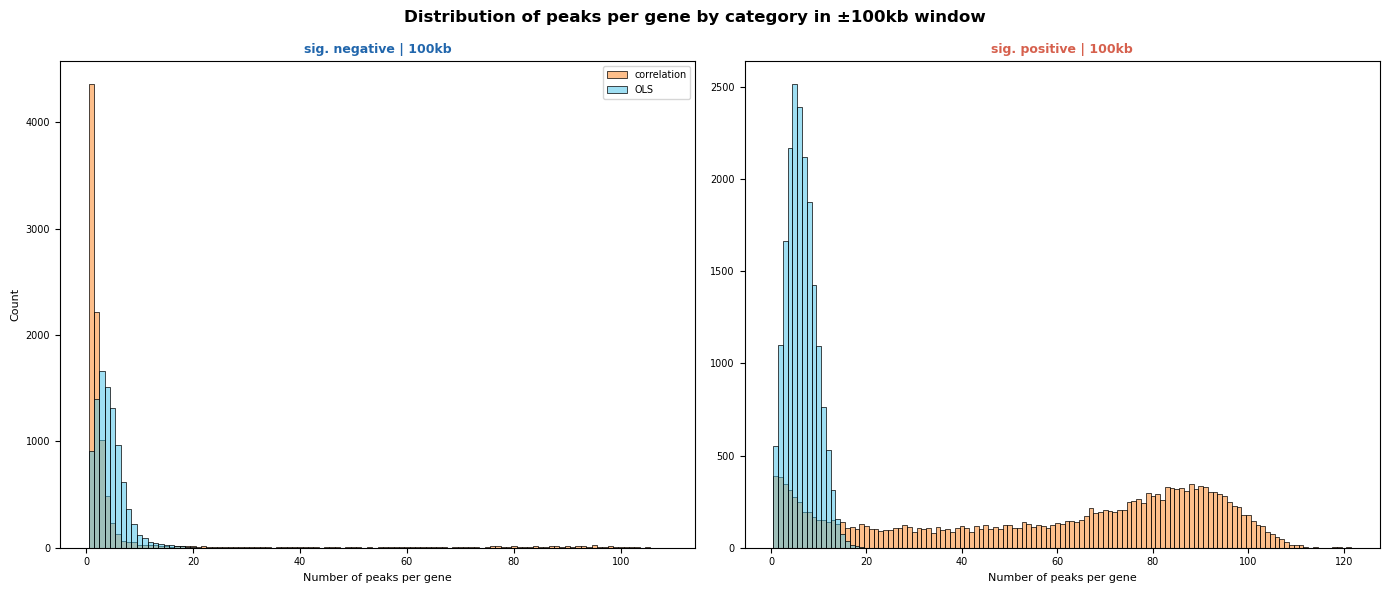

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

plot_df = agg_merged_df.dropna(subset=["count_cor", "count_ols", "window", "category", "gene"]).copy()
plot_df["window"] = pd.Categorical(
    plot_df["window"], categories=["100kb"], ordered=True,
)
plot_df["category"] = pd.Categorical(
    plot_df["category"],
    categories=["sig. negative", "non-significant", "sig. positive"], ordered=True,
)

plot_sig_df = plot_df[plot_df["category"] != "non-significant"].copy()
plot_sig_df["category"] = pd.Categorical(
    plot_sig_df["category"],
    categories=["sig. negative", "sig. positive"],
    ordered=True,
)

# Deduplicate to one row per unique (x, y, window, category) position
plot_dedup = plot_sig_df.drop_duplicates(
    subset=["count_cor", "count_ols", "window", "category"]
).copy()
category_order = ["sig. negative", "sig. positive"]
window_labels = ["100kb"]
method_colors = {"correlation": "#fd7e16", "OLS": "#40c1e9"}

fig, axes = plt.subplots(len(window_labels),2, figsize=(14, 6), sharex=False, sharey=False)

for row_idx, win in enumerate(window_labels):
    win_data = plot_sig_df[plot_sig_df["window"] == win]

    for col_idx, cat in enumerate(category_order):
        ax = axes[col_idx]
        cat_data = win_data[win_data["category"] == cat]

        combined_counts = pd.concat([win_data["count_cor"], win_data["count_ols"]]).dropna()
        if combined_counts.empty:
            ax.set_axis_off()
            continue

        bin_edges = np.linspace(combined_counts.min(), combined_counts.max(), 16)
        if np.unique(bin_edges).size < 2:
            bin_edges = np.array([combined_counts.min() - 0.5, combined_counts.max() + 0.5])

        # Plot correlation histogram
        sns.histplot(
            cat_data["count_cor"],
            #bins=bin_edges,
            alpha=0.5,
            label="correlation",
            color=method_colors["correlation"],
            edgecolor="black",
            linewidth=0.5,
            discrete=True,
            ax = ax

        )
        # Plot OLS histogram
        sns.histplot(
            cat_data["count_ols"],
            #bins=bin_edges,
            alpha=0.5,
            label="OLS",
            color=method_colors["OLS"],
            edgecolor="black",
            linewidth=0.5,
            discrete=True,
            ax = ax
        )

        ax.set_xlabel("Number of peaks per gene", fontsize=8)
        ax.set_ylabel("Count" if col_idx == 0 else "", fontsize=8)
        ax.set_title(f"{cat} | {win}", fontsize=9, fontweight="bold", color="#2166ac" if cat == "sig. negative" else "#d6604d")
        ax.tick_params(labelsize=7)

        if row_idx == 0 and col_idx == 0:
            ax.legend(loc="upper right", fontsize=7)

fig.suptitle("Distribution of peaks per gene by category in ±100kb window", fontsize=12, fontweight="bold", y=0.98)
plt.tight_layout()
plt.show()

# Gene annotation to genes in ols and cor results

In [ ]:
#load the window_assignment_with_peak_counts_100kb.csv file to check if the new columns are there
import pandas as pd
window_assignment = pd.read_csv("/home/fgsasse_lrs_1/Downloads/BA/BA_data/Overlaps OLS vs Cor/window_assignment_with_peak_counts_100kb.csv")
window_assignment.head()

#load the ols and correlation results dataframes
ols_100kb_df = pd.read_csv("/home/fgsasse_lrs_1/Downloads/BA/BA_data/OLS/Results/ols_res_all_windows_range_df_ct_time.csv")
cor_100kb_df = pd.read_csv("/home/fgsasse_lrs_1/Downloads/BA/BA_data/Correlations/Results/gene_peak_correlation_ct_time_100kb_results.csv")

In [ ]:
print(ols_100kb_df.head())
print(cor_100kb_df.head())

In [ ]:
# classify every peak–gene pair into one of three categories to cor results

def classify_pair(row):
    if row["padj"] <= 0.05 and row["correlation"] < 0:
        return "sig. negative"
    elif row["padj"] <= 0.05 and row["correlation"] > 0:
        return "sig. positive"
    else:
        return "non-significant"

cor_100kb_df["category"] = cor_100kb_df.apply(classify_pair, axis=1)
cor_100kb_df.head()

add the window_assignment information to both dataframes by merging on gene_id

In [ ]:
#rename window_assignment gene_id column to gene to match the cor_100kb_df dataframe
window_assignment = window_assignment.rename(columns={"gene_id": "gene"})

#merge on gene_id and assign the peak_count_window to the cor_100kb_df dataframe
cor_100kb_df = cor_100kb_df.merge(window_assignment[["gene", "peak_count_window"]], on="gene", how="left")
print(cor_100kb_df.head())

In [ ]:
#add the window_assignment information to the ols_100kb_df dataframe by merging on gene
ols_100kb_df = ols_100kb_df.merge(window_assignment[["gene", "peak_count_window"]], on="gene", how="left")
print(ols_100kb_df.head())

In [ ]:
#sort the dataframe by the peak_count_window column ascending
ols_100kb_df = ols_100kb_df.sort_values("peak_count_window")
cor_100kb_df = cor_100kb_df.sort_values("peak_count_window")
cor_100kb_df.head()

In [ ]:
window_labels = [window_assignment["peak_count_window"].sort_values().unique()]
window_labels

Computing jaccard and retention score